# News Classification - NLP Pipeline

## Projet de Classification d'Articles d'Actualité

Ce notebook implémente une pipeline NLP complète pour classifier automatiquement les articles d'actualité en 4 catégories :
- **World** (0) : Actualités mondiales
- **Sports** (1) : Sports
- **Business** (2) : Affaires et économie
- **Sci/Tech** (3) : Science et technologie

### Étapes du pipeline :
1. Chargement des données depuis Hugging Face (SetFit/ag_news)
2. Conversion en DataFrame pandas
3. Analyse exploratoire des données (EDA)
4. Prétraitement des textes
5. Génération des embeddings avec Sentence Transformers

In [1]:
# Import des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter

# Bibliothèques NLP
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
import nltk

# Télécharger les stopwords
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords

# Configuration de l'affichage
sns.set(style='whitegrid')
pd.set_option('display.max_colwidth', 100)
print("✅ Bibliothèques importées avec succès!")

✅ Bibliothèques importées avec succès!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\redaj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\redaj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## 1. Chargement des Données depuis Hugging Face

Nous utilisons le dataset **SetFit/ag_news** qui contient des articles d'actualité classés en 4 catégories.

In [2]:
# Chargement du dataset depuis Hugging Face
print("⏳ Chargement du dataset SetFit/ag_news...")
dataset = load_dataset("SetFit/ag_news")

# Afficher la structure du dataset
print("\n📊 Structure du dataset:")
print(dataset)

# Afficher les splits disponibles
print("\n📁 Splits disponibles:", list(dataset.keys()))

⏳ Chargement du dataset SetFit/ag_news...


train.jsonl:   0%|          | 0.00/33.8M [00:00<?, ?B/s]

C:\Users\redaj\AppData\Roaming\Python\Python312\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\redaj\.cache\huggingface\hub\datasets--SetFit--ag_news. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


test.jsonl:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]


📊 Structure du dataset:
DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 7600
    })
})

📁 Splits disponibles: ['train', 'test']


## 2. Conversion en DataFrame Pandas

In [3]:
# Conversion du dataset en DataFrame pandas
df_train = pd.DataFrame(dataset['train'])
df_test = pd.DataFrame(dataset['test'])

# Combiner train et test pour l'analyse (optionnel)
df = pd.concat([df_train, df_test], ignore_index=True)

# Mapping des labels numériques vers les noms de catégories
label_mapping = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
df['category'] = df['label'].map(label_mapping)

print(f"📊 Dimensions du DataFrame:")
print(f"   - Train: {len(df_train)} articles")
print(f"   - Test: {len(df_test)} articles")
print(f"   - Total: {len(df)} articles")

print("\n📝 Colonnes disponibles:", df.columns.tolist())
print("\n🔍 Aperçu des données:")
df.head()

📊 Dimensions du DataFrame:
   - Train: 120000 articles
   - Test: 7600 articles
   - Total: 127600 articles

📝 Colonnes disponibles: ['text', 'label', 'label_text', 'category']

🔍 Aperçu des données:


,text,label,label_text,category
0,"Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindli...",2,Business,Business
1,Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Gr...,2,Business,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\abou...,2,Business,Business
3,Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted o...,2,Business,Business
4,"Oil prices soar to all-time record, posing new menace to US economy (AFP) AFP - Tearaway world o...",2,Business,Business


## 3. Analyse Exploratoire des Données (EDA)

### 3.1 Informations générales sur le dataset

In [4]:
# Informations sur le DataFrame
print("📋 Informations sur le DataFrame:")
print("="*50)
df.info()

print("\n📊 Statistiques descriptives:")
df.describe(include='all')

📋 Informations sur le DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127600 entries, 0 to 127599
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   text        127600 non-null  object
 1   label       127600 non-null  int64 
 2   label_text  127600 non-null  object
 3   category    127600 non-null  object
dtypes: int64(1), object(3)
memory usage: 3.9+ MB

📊 Statistiques descriptives:


,text,label,label_text,category
count,127600,127600.000000,127600,127600
unique,127600,NaN,4,4
top,Right-hander must pass physical Right-hander Matt Clement and the Boston Red Sox agreed Friday t...,NaN,Business,Business
freq,1,NaN,31900,31900
mean,NaN,1.500000,NaN,NaN
std,NaN,1.118038,NaN,NaN
min,NaN,0.000000,NaN,NaN
25%,NaN,0.750000,NaN,NaN
50%,NaN,1.500000,NaN,NaN
75%,NaN,2.250000,NaN,NaN


In [5]:
# Vérification des valeurs manquantes
print("🔍 Valeurs manquantes par colonne:")
missing_values = df.isnull().sum()
print(missing_values)

# Vérification des doublons
duplicates = df.duplicated(subset=['text']).sum()
print(f"\n🔄 Nombre de doublons (basé sur le texte): {duplicates}")

🔍 Valeurs manquantes par colonne:
text          0
label         0
label_text    0
category      0
dtype: int64

🔄 Nombre de doublons (basé sur le texte): 0


### 3.2 Distribution des catégories

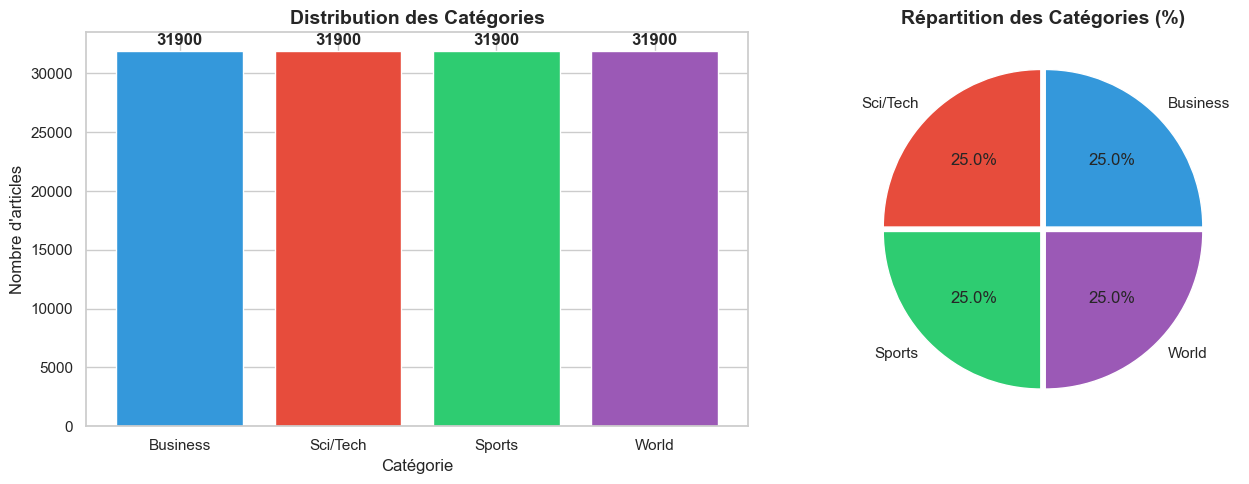


📊 Répartition des catégories:
category
Business    31900
Sci/Tech    31900
Sports      31900
World       31900
Name: count, dtype: int64


In [6]:
# Distribution des catégories
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique en barres
category_counts = df['category'].value_counts()
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
axes[0].bar(category_counts.index, category_counts.values, color=colors)
axes[0].set_title('Distribution des Catégories', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Catégorie')
axes[0].set_ylabel('Nombre d\'articles')
for i, v in enumerate(category_counts.values):
    axes[0].text(i, v + 500, str(v), ha='center', fontweight='bold')

# Graphique en camembert
axes[1].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', 
            colors=colors, explode=[0.02]*4)
axes[1].set_title('Répartition des Catégories (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Répartition des catégories:")
print(category_counts)

### 3.3 Analyse de la longueur des textes

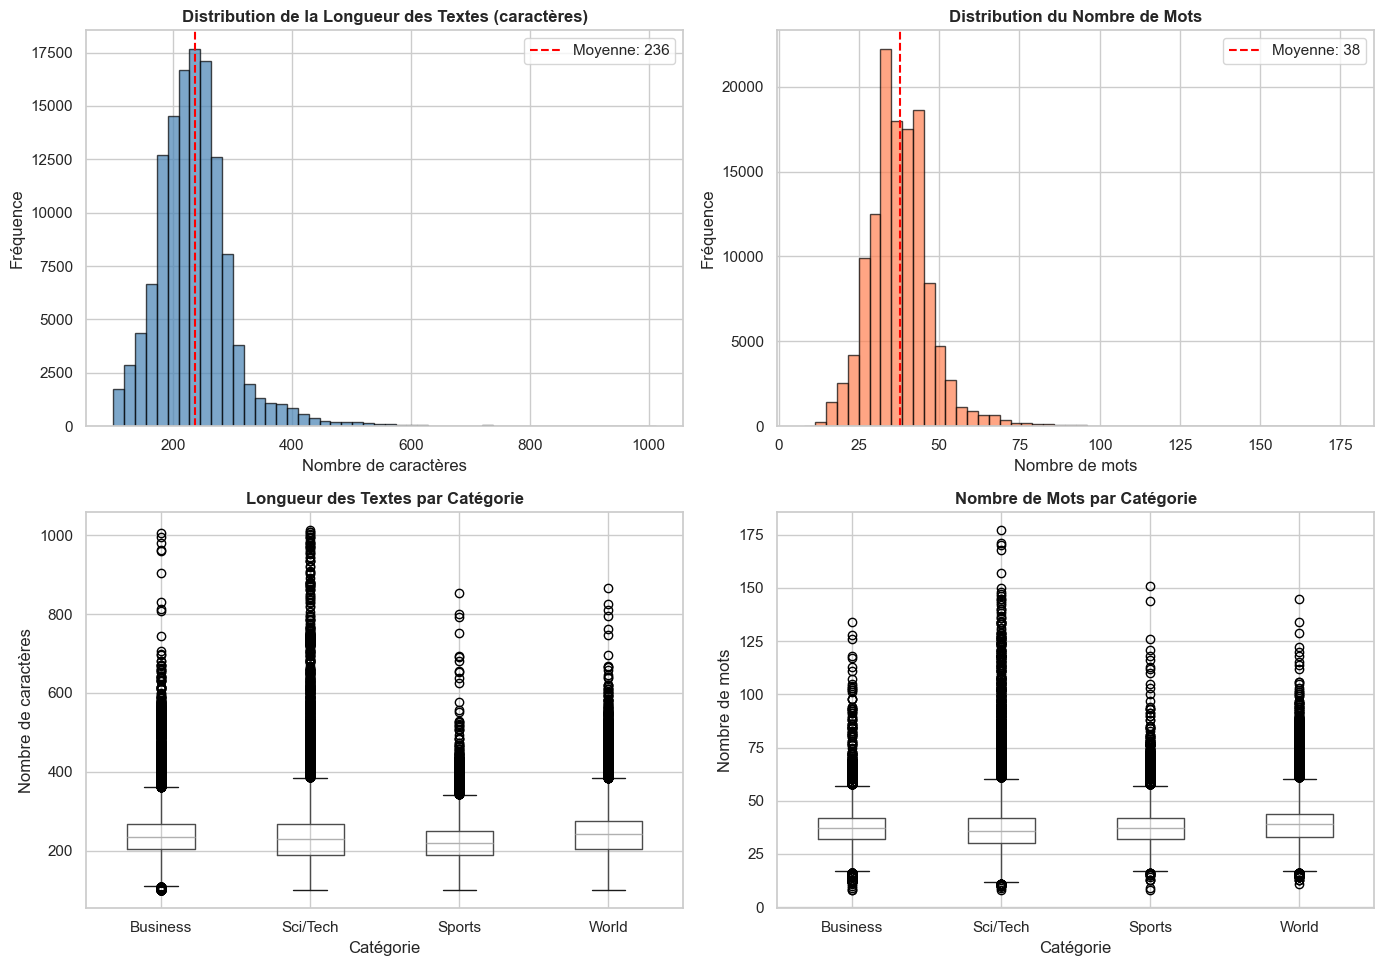


📊 Statistiques sur la longueur des textes:
         text_length     word_count
count  127600.000000  127600.000000
mean      236.407343      37.840000
std        66.438756      10.087912
min       100.000000       8.000000
25%       196.000000      32.000000
50%       232.000000      37.000000
75%       266.000000      43.000000
max      1012.000000     177.000000


In [7]:
# Analyse de la longueur des textes
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution de la longueur des caractères
axes[0, 0].hist(df['text_length'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution de la Longueur des Textes (caractères)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Nombre de caractères')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].axvline(df['text_length'].mean(), color='red', linestyle='--', label=f'Moyenne: {df["text_length"].mean():.0f}')
axes[0, 0].legend()

# Distribution du nombre de mots
axes[0, 1].hist(df['word_count'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribution du Nombre de Mots', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Nombre de mots')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Moyenne: {df["word_count"].mean():.0f}')
axes[0, 1].legend()

# Boxplot par catégorie (longueur)
df.boxplot(column='text_length', by='category', ax=axes[1, 0])
axes[1, 0].set_title('Longueur des Textes par Catégorie', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Catégorie')
axes[1, 0].set_ylabel('Nombre de caractères')
plt.suptitle('')

# Boxplot par catégorie (mots)
df.boxplot(column='word_count', by='category', ax=axes[1, 1])
axes[1, 1].set_title('Nombre de Mots par Catégorie', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Catégorie')
axes[1, 1].set_ylabel('Nombre de mots')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\n📊 Statistiques sur la longueur des textes:")
print(df[['text_length', 'word_count']].describe())

### 3.4 Analyse des mots les plus fréquents

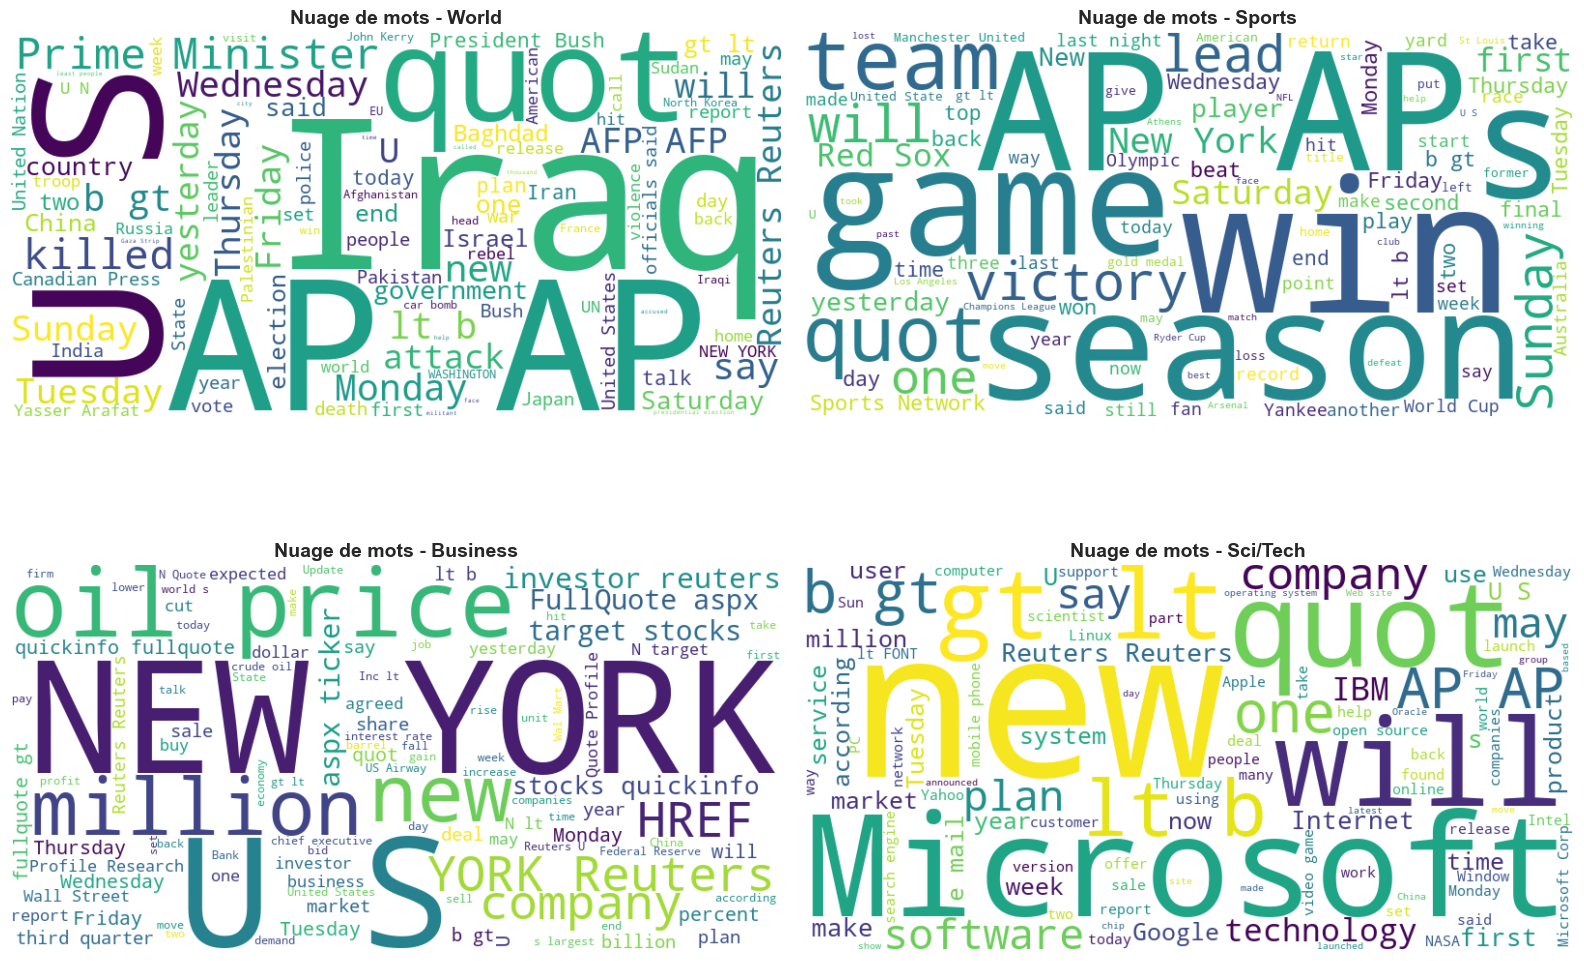

In [8]:
# Analyse des mots les plus fréquents par catégorie
from wordcloud import WordCloud

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, category in enumerate(label_mapping.values()):
    text = ' '.join(df[df['category'] == category]['text'].tolist())
    wordcloud = WordCloud(width=800, height=400, background_color='white', 
                          max_words=100, colormap='viridis').generate(text)
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Nuage de mots - {category}', fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 4. Prétraitement des Textes

Le prétraitement comprend :
- **Normalisation** : Conversion en minuscules
- **Suppression des doublons**
- **Suppression des stopwords** : Mots courants sans valeur sémantique
- **Suppression de la ponctuation** : À l'aide d'expressions régulières (regex)

In [9]:
# Définition des fonctions de prétraitement

# Charger les stopwords anglais
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Fonction de prétraitement du texte :
    1. Normalisation (minuscules)
    2. Suppression de la ponctuation (regex)
    3. Suppression des stopwords
    """
    # 1. Normalisation - conversion en minuscules
    text = text.lower()
    
    # 2. Suppression de la ponctuation avec regex
    text = re.sub(r'[^\w\s]', '', text)
    
    # 3. Suppression des chiffres (optionnel)
    text = re.sub(r'\d+', '', text)
    
    # 4. Suppression des espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 5. Suppression des stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    return ' '.join(words)

# Test de la fonction
sample_text = df['text'].iloc[0]
print("📝 Texte original:")
print(sample_text)
print("\n✅ Texte prétraité:")
print(preprocess_text(sample_text))

📝 Texte original:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

✅ Texte prétraité:
wall st bears claw back black reuters reuters shortsellers wall streets dwindlingband ultracynics seeing green


In [10]:
# Suppression des doublons
print(f"📊 Nombre d'articles avant suppression des doublons: {len(df)}")
df_clean = df.drop_duplicates(subset=['text'], keep='first').copy()
print(f"✅ Nombre d'articles après suppression des doublons: {len(df_clean)}")
print(f"🗑️ Doublons supprimés: {len(df) - len(df_clean)}")

📊 Nombre d'articles avant suppression des doublons: 127600
✅ Nombre d'articles après suppression des doublons: 127600
🗑️ Doublons supprimés: 0


In [11]:
# Application du prétraitement à tous les textes
print("⏳ Application du prétraitement aux textes...")
df_clean['text_clean'] = df_clean['text'].apply(preprocess_text)

print("✅ Prétraitement terminé!")

# Afficher quelques exemples
print("\n📝 Exemples de textes prétraités:")
for i in range(3):
    print(f"\n--- Article {i+1} ---")
    print(f"Original: {df_clean['text'].iloc[i][:100]}...")
    print(f"Prétraité: {df_clean['text_clean'].iloc[i][:100]}...")

⏳ Application du prétraitement aux textes...
✅ Prétraitement terminé!

📝 Exemples de textes prétraités:

--- Article 1 ---
Original: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\b...
Prétraité: wall st bears claw back black reuters reuters shortsellers wall streets dwindlingband ultracynics se...

--- Article 2 ---
Original: Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,...
Prétraité: carlyle looks toward commercial aerospace reuters reuters private investment firm carlyle groupwhich...

--- Article 3 ---
Original: Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about th...
Prétraité: oil economy cloud stocks outlook reuters reuters soaring crude prices plus worriesabout economy outl...
✅ Prétraitement terminé!

📝 Exemples de textes prétraités:

--- Article 1 ---
Original: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Shor

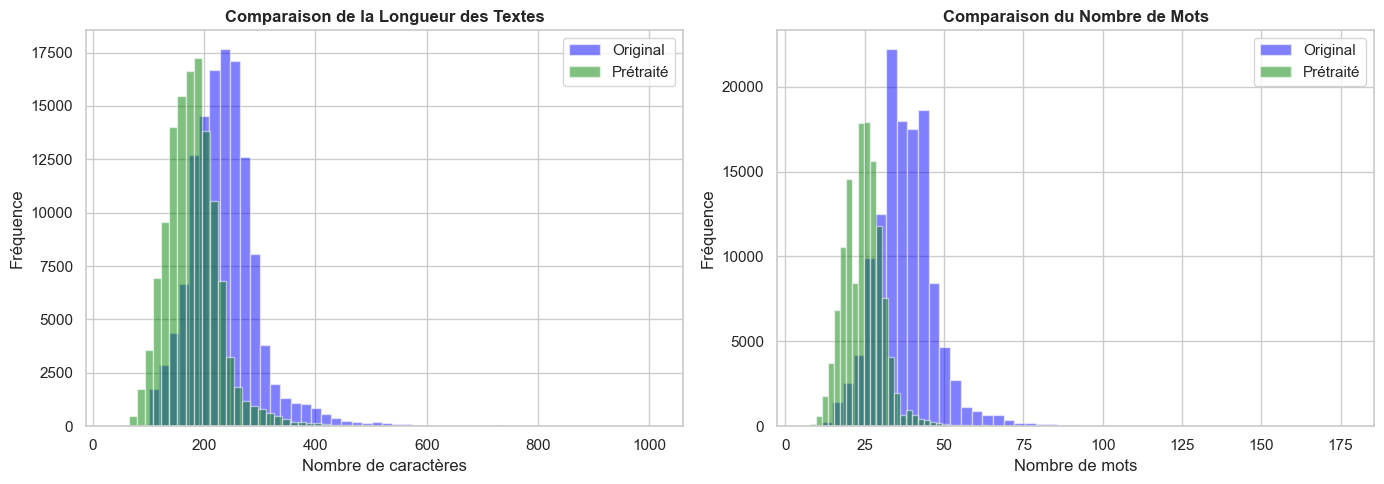


📊 Statistiques avant/après prétraitement:
Longueur moyenne (avant): 236 caractères
Longueur moyenne (après): 180 caractères
Nombre de mots moyen (avant): 38
Nombre de mots moyen (après): 25


In [12]:
# Comparaison avant/après prétraitement
df_clean['clean_text_length'] = df_clean['text_clean'].apply(len)
df_clean['clean_word_count'] = df_clean['text_clean'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparaison de la longueur
axes[0].hist(df_clean['text_length'], bins=50, alpha=0.5, label='Original', color='blue')
axes[0].hist(df_clean['clean_text_length'], bins=50, alpha=0.5, label='Prétraité', color='green')
axes[0].set_title('Comparaison de la Longueur des Textes', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nombre de caractères')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

# Comparaison du nombre de mots
axes[1].hist(df_clean['word_count'], bins=50, alpha=0.5, label='Original', color='blue')
axes[1].hist(df_clean['clean_word_count'], bins=50, alpha=0.5, label='Prétraité', color='green')
axes[1].set_title('Comparaison du Nombre de Mots', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nombre de mots')
axes[1].set_ylabel('Fréquence')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n📊 Statistiques avant/après prétraitement:")
print(f"Longueur moyenne (avant): {df_clean['text_length'].mean():.0f} caractères")
print(f"Longueur moyenne (après): {df_clean['clean_text_length'].mean():.0f} caractères")
print(f"Nombre de mots moyen (avant): {df_clean['word_count'].mean():.0f}")
print(f"Nombre de mots moyen (après): {df_clean['clean_word_count'].mean():.0f}")

## 5. Génération des Embeddings avec Sentence Transformers

Nous utilisons le modèle **paraphrase-multilingual-MiniLM-L12-v2** pour générer des représentations vectorielles (embeddings) des textes.

In [13]:
# Chargement du modèle Sentence Transformer
print("⏳ Chargement du modèle paraphrase-multilingual-MiniLM-L12-v2...")
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print("✅ Modèle chargé avec succès!")

# Afficher les informations sur le modèle
print(f"\n📊 Informations sur le modèle:")
print(f"   - Dimension des embeddings: {model.get_sentence_embedding_dimension()}")

⏳ Chargement du modèle paraphrase-multilingual-MiniLM-L12-v2...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

C:\Users\redaj\AppData\Roaming\Python\Python312\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\redaj\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Modèle chargé avec succès!

📊 Informations sur le modèle:
   - Dimension des embeddings: 384


In [ ]:
# Génération des embeddings pour un échantillon (pour démonstration)
# Note: Pour le dataset complet, cela peut prendre plusieurs minutes

# Utiliser un échantillon pour la démonstration
sample_size = 1000
df_sample = df_clean.sample(n=sample_size, random_state=42)

print(f"⏳ Génération des embeddings pour {sample_size} articles...")
embeddings = model.encode(
    df_sample['text_clean'].tolist(),
    show_progress_bar=True,
    batch_size=32
)

print(f"\n✅ Embeddings générés avec succès!")
print(f"📊 Dimensions des embeddings: {embeddings.shape}")
print(f"   - Nombre d'articles: {embeddings.shape[0]}")
print(f"   - Dimension de chaque vecteur: {embeddings.shape[1]}")

In [ ]:
# Visualisation des embeddings avec réduction de dimensionnalité (t-SNE)
from sklearn.manifold import TSNE

print("⏳ Réduction de dimensionnalité avec t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)

# Créer un DataFrame pour la visualisation
viz_df = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'category': df_sample['category'].values
})

# Visualisation
plt.figure(figsize=(12, 8))
colors = {'World': '#3498db', 'Sports': '#e74c3c', 'Business': '#2ecc71', 'Sci/Tech': '#9b59b6'}
for category in colors.keys():
    subset = viz_df[viz_df['category'] == category]
    plt.scatter(subset['x'], subset['y'], c=colors[category], label=category, alpha=0.6, s=20)

plt.title('Visualisation t-SNE des Embeddings par Catégorie', fontsize=14, fontweight='bold')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.tight_layout()
plt.show()

print("✅ Visualisation terminée!")

## 6. Résumé et Sauvegarde

### Récapitulatif de la Pipeline NLP

In [ ]:
# Résumé de la pipeline
print("=" * 60)
print("📊 RÉSUMÉ DE LA PIPELINE NLP")
print("=" * 60)

print("\n1️⃣ CHARGEMENT DES DONNÉES:")
print(f"   ✓ Source: Hugging Face (SetFit/ag_news)")
print(f"   ✓ Nombre total d'articles: {len(df)}")

print("\n2️⃣ CATÉGORIES:")
for label, name in label_mapping.items():
    count = len(df[df['label'] == label])
    print(f"   ✓ {name} ({label}): {count} articles")

print("\n3️⃣ PRÉTRAITEMENT:")
print(f"   ✓ Doublons supprimés: {len(df) - len(df_clean)}")
print(f"   ✓ Articles restants: {len(df_clean)}")
print(f"   ✓ Techniques appliquées:")
print(f"      - Normalisation (minuscules)")
print(f"      - Suppression de la ponctuation (regex)")
print(f"      - Suppression des stopwords")

print("\n4️⃣ EMBEDDINGS:")
print(f"   ✓ Modèle: paraphrase-multilingual-MiniLM-L12-v2")
print(f"   ✓ Dimension: {embeddings.shape[1]} dimensions")
print(f"   ✓ Échantillon traité: {sample_size} articles")

print("\n" + "=" * 60)
print("✅ Pipeline NLP terminée avec succès!")
print("=" * 60)

In [ ]:
# Sauvegarde des données prétraitées et des embeddings
import os

# Créer le dossier de sortie s'il n'existe pas
output_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)

# Sauvegarder le DataFrame prétraité
df_clean.to_csv(f'{output_dir}/ag_news_preprocessed.csv', index=False)
print(f"✅ Données prétraitées sauvegardées: {output_dir}/ag_news_preprocessed.csv")

# Sauvegarder les embeddings de l'échantillon
np.save(f'{output_dir}/embeddings_sample.npy', embeddings)
print(f"✅ Embeddings sauvegardés: {output_dir}/embeddings_sample.npy")

# Sauvegarder les labels correspondants
np.save(f'{output_dir}/labels_sample.npy', df_sample['label'].values)
print(f"✅ Labels sauvegardés: {output_dir}/labels_sample.npy")

print("\n🎉 Toutes les données ont été sauvegardées avec succès!")